# ***COAST DOWN***

Resumo da etapa de reducao de resistencia e preparacao dos dados de VDE para modelagem.


## 1 - Setup Inicial

Carrega dependencias, abre o banco SQLite e combina tabelas relevantes para analise.


In [55]:
import sqlite3
import pandas as pd
from pathlib import Path

In [56]:
# Caminho do arquivo .db
db_path = "data/db/eco_drive.db"

# Abrindo conexão com o banco
conn = sqlite3.connect(db_path)

# Listando as tabelas disponíveis
query_tables = "SELECT name FROM sqlite_master WHERE type='table';"
tabelas = pd.read_sql_query(query_tables, conn)

# Habilitando chaves estrangeiras
conn.execute("PRAGMA foreign_keys=ON;")

# Realizando JOIN entre as tabelas vde_db e fuelcons_db
df_all=pd.read_sql("""
SELECT *
FROM vde_db v
JOIN fuelcons_db f ON f.vde_id = v.id
ORDER BY v.id ASC
""", conn)

df_all.head(3)

,id,created_at,updated_at,legislation,category,make,model,year,notes,engine_type,...,label_version_year,label_vehicle_category,label_cycle_set,label_class,label_offcycle_method,label_offcycle_energy_factor,label_offcycle_fuel_factor,label_fuel_l_per_100km,label_gco2_per_km,label_range_km
0,1,2025-10-07 05:15:33,None,EPA,MINICOMPACT CARS,ASTON MARTIN,DB12 V8,2025,From EPA test car dataset,None,...,2025.0,Minicompact Cars,2-cycle,None,None,None,None,10.450970,244.718780,None
1,2,2025-10-07 05:15:33,None,EPA,STANDARD SUVS,ASTON MARTIN,DBX 707,2025,From EPA test car dataset,None,...,2025.0,Standard SUVs,2-cycle,None,None,None,None,10.884284,259.036291,None
2,3,2025-10-07 05:15:33,None,EPA,TWO SEATERS,ASTON MARTIN,VANQUISH,2025,From EPA test car dataset,None,...,2025.0,Two Seaters,2-cycle,None,None,None,None,11.550805,273.798858,None


In [57]:
df_all.shape

(5004, 139)

-- --

## 2 - Limpeza dos Dados

Aplica filtro inicial e verifica nulidade para garantir integridade antes da modelagem.


In [60]:
# Filtrando linhas específicas do DataFrame
df_filtred = df_all.iloc[1:4999, :]
df_filtred.shape
df_filtred.loc[df_filtred["engine_size_l"] > 90, "engine_size_l"] = 0.001


In [61]:
# Selecionando features
X = df_filtred[
    [
        "category",
        "make",
        "year",
        "engine_size_l",
        "transmission_type",
        "drive_type",
        "electrification",
        "gear_count",
        "final_drive_ratio",
    ]
]

# Selecionando targets
y = df_filtred[
    ["coast_A_N",
    "coast_B_N_per_kph",
    "coast_C_N_per_kph2",
    "vde_net_mj_per_km"]
]

X.shape, y.shape

((4998, 9), (4998, 4))

In [62]:
# Analisando estatísticas descritivas dos targets
y.describe()

,coast_A_N,coast_B_N_per_kph,coast_C_N_per_kph2,vde_net_mj_per_km
count,4998.000000,4998.000000,4998.000000,4998.000000
mean,185.846055,0.583356,0.040521,0.574741
std,55.643986,0.818328,0.011711,0.108253
min,71.697071,-2.148455,0.016144,0.316618
25%,144.863751,0.100057,0.032349,0.500052
50%,179.515545,0.585415,0.038748,0.561186
75%,216.672875,1.099242,0.046425,0.631161
max,411.705152,4.325655,0.113353,1.161238


-- --

## 3 - Analise Exploratoria

Explora distribuicoes e correlacoes das variaveis para entender padroes e sinais fortes.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

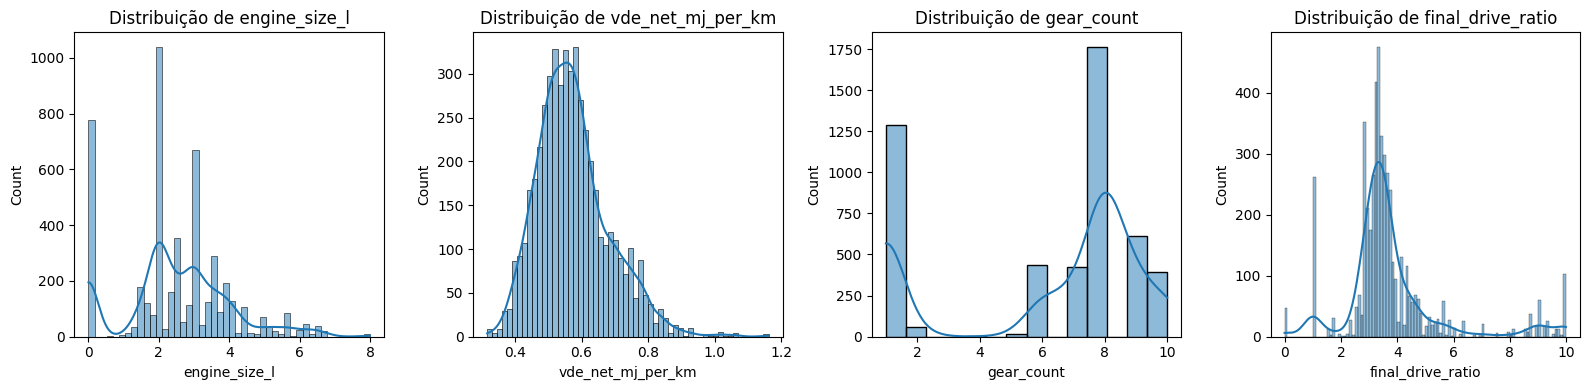

In [63]:
# Selecionar apenas variáveis numéricas
numeric_vars = X.select_dtypes(include=['number']).columns.tolist()

# Gráfico para a análise multivariada entre as variáveis numéricas e a variável Case
plt.figure(figsize=(16, 4))

# Variáveis a serem plotadas
plot_vars = []
for v in ["engine_size_l", "vde_net_mj_per_km", "gear_count", "final_drive_ratio"]:
    if v in df_filtred.columns:
        plot_vars.append(v)

# Criando subplots para cada variável
for i, var in enumerate(plot_vars, 1):
    plt.subplot(1, len(plot_vars), i)
    sns.histplot(data=df_filtred, x=var, kde=True)
    plt.title(f"Distribuição de {var}")
    plt.tight_layout()

plt.show()

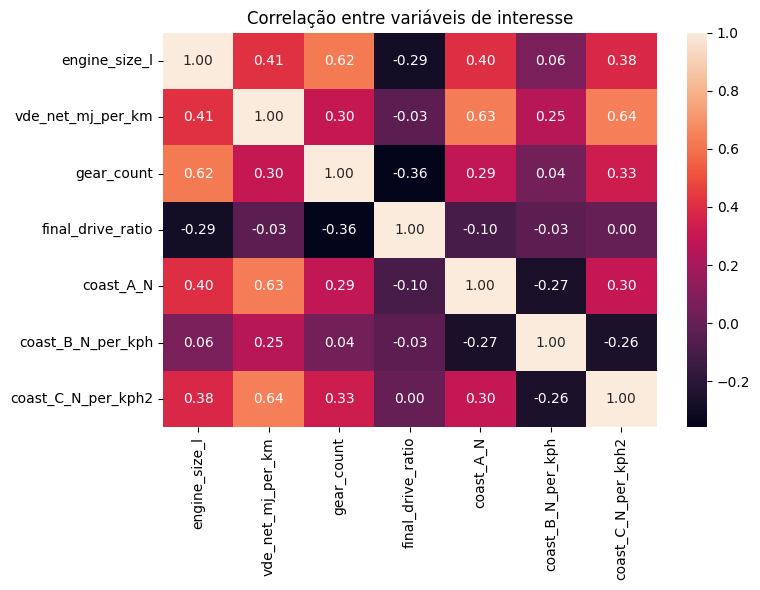

In [64]:
corr_cols = []

# Selecionando colunas para a matriz de correlação
for v in [
    "engine_size_l",
    "vde_net_mj_per_km",
    "gear_count",
    "final_drive_ratio",
    "coast_A_N",
    "coast_B_N_per_kph",
    "coast_C_N_per_kph2",
]:
    if v in df_filtred.columns:
        corr_cols.append(v)

# Calculando a matriz de correlação
corr_matrix = df_filtred[corr_cols].corr()

# Plotando a matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlação entre variáveis de interesse")
plt.tight_layout()
plt.show()

-- --

## 4 - Pre-processamento

Define colunas numericas e categoricas, com escalonamento e one-hot, preparando o pipeline.


In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [66]:
X.isnull().sum()

category             0
make                 0
year                 0
engine_size_l        0
transmission_type    0
drive_type           0
electrification      0
gear_count           0
final_drive_ratio    0
dtype: int64

In [67]:
X.head()

,category,make,year,engine_size_l,transmission_type,drive_type,electrification,gear_count,final_drive_ratio
1,STANDARD SUVS,ASTON MARTIN,2025,4.0,AT,4WD,ICE,9,3.27
2,TWO SEATERS,ASTON MARTIN,2025,5.2,AT,RWD,ICE,8,2.93
3,TWO SEATERS,ASTON MARTIN,2025,4.0,AT,RWD,ICE,8,3.08
4,SUBCOMPACT CARS,BMW,2025,2.0,AMT,RWD,ICE,8,2.81
5,SUBCOMPACT CARS,BMW,2025,2.0,AMT,AWD,ICE,8,2.81


In [68]:
# Definindo pré-processamento para features contínuas e categóricas
continuous_features = [
    "engine_size_l",
    "gear_count",
    "final_drive_ratio",
    "year"
]

categorical_features = [
    "category",
    "make",
    "transmission_type",
    "drive_type",
    "electrification",
]

# Configurando o pré-processador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features), # scaling para variáveis contínuas
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # codificação para variáveis categóricas
    ],
     remainder='passthrough' #  manter outras colunas sem alterações
)

-- --

## 5 - Treinamento dos Modelos

Divide em treino/teste e avalia diferentes regressoes multialvo com metricas MAE e R2.


In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [71]:
# Função para gerar relatório de regressão
def regression_report(y_true, y_pred, target_names=None):
    if target_names is None:
        target_names = [f"target_{i}" for i in range(y_true.shape[1])]

    for i, name in enumerate(target_names):
        mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2   = r2_score(y_true[:, i], y_pred[:, i])

        print(f"=== {name} ===")
        print(f"MAE : {mae:.4f}")
        print(f"R²  : {r2:.4f}")
        print()

### 5.1 - Linear Regression

In [72]:
model_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model_1.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [73]:
y_pred_1 = model_1.predict(X_test)

regression_report(y_test.values, y_pred_1, target_names=y_test.columns)

=== coast_A_N ===
MAE : 26.5893
R²  : 0.6311

=== coast_B_N_per_kph ===
MAE : 0.4467
R²  : 0.4723

=== coast_C_N_per_kph2 ===
MAE : 0.0050
R²  : 0.6519

=== vde_net_mj_per_km ===
MAE : 0.0406
R²  : 0.7379



-- --

### 5.2 - Random Forest

In [76]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [77]:
model_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=180, random_state=42))
])

model_2.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [78]:
y_pred_2 = model_2.predict(X_test)
regression_report(y_test.values, y_pred_2, target_names=y_test.columns)

=== coast_A_N ===
MAE : 14.6529
R²  : 0.8488

=== coast_B_N_per_kph ===
MAE : 0.2123
R²  : 0.8302

=== coast_C_N_per_kph2 ===
MAE : 0.0025
R²  : 0.8839

=== vde_net_mj_per_km ===
MAE : 0.0232
R²  : 0.9008



-- --

### 5.3 - Neural Network

In [79]:
from sklearn.neural_network import MLPRegressor

In [80]:
model_3 = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            MLPRegressor(
                hidden_layer_sizes=(100, 50),
                activation="logistic",
                solver="adam",
                learning_rate="adaptive",
                random_state=42,
                early_stopping=True,
                alpha=0.001,
                max_iter=1000
            ),
        ),
    ]
)

model_3.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [81]:
y_pred_3 = model_3.predict(X_test)
regression_report(y_test.values, y_pred_3, target_names=y_test.columns)

=== coast_A_N ===
MAE : 42.8898
R²  : -0.0061

=== coast_B_N_per_kph ===
MAE : 0.6115
R²  : -0.0053

=== coast_C_N_per_kph2 ===
MAE : 0.0088
R²  : 0.0048

=== vde_net_mj_per_km ===
MAE : 0.0837
R²  : -0.0141



-- --

### 5.4 - SVM

In [82]:
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

In [83]:
model_4 = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            MultiOutputRegressor(
                SVR(kernel="rbf", C=10, gamma='scale', epsilon=0.1)
            ),
        ),
    ]
)

model_4.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [84]:
y_pred_4 = model_4.predict(X_test)
regression_report(y_test.values, y_pred_4, target_names=y_test.columns)

=== coast_A_N ===
MAE : 22.5693
R²  : 0.6760

=== coast_B_N_per_kph ===
MAE : 0.2293
R²  : 0.8157

=== coast_C_N_per_kph2 ===
MAE : 0.0254
R²  : -4.5142

=== vde_net_mj_per_km ===
MAE : 0.0477
R²  : 0.7144



-- --

# ***FUEL CONSUMPTION***

Modelagem de consumo de combustivel/energia a partir das variaveis de VDE e coastdown.


In [85]:
# Selecionando features
X_fc = df_filtred[
    [
        "category",
        "make",
        "year",
        "engine_size_l",
        "transmission_type",
        "drive_type",
        "electrification",
        "gear_count",
        "final_drive_ratio",
        "coast_A_N",
        "coast_B_N_per_kph",
        "coast_C_N_per_kph2",
        "vde_net_mj_per_km",
        "vde_urb_mj_per_km",
        "vde_hw_mj_per_km",
    ]
]

# Selecionando targets
y_fc = df_filtred[
    [
        "fuel_ftp75_l_per_100km",
        "fuel_hwfet_l_per_100km",
        "fuel_l_per_100km",
        "energy_ftp75_Wh_per_km",
        "energy_hwfet_Wh_per_km",
        "energy_Wh_per_km",
    ]
]

X_fc.shape, y_fc.shape

((4998, 15), (4998, 6))

In [86]:
X_fc_nbev = X_fc[X_fc["electrification"] != "BEV"]

y_fc_nbev = y_fc[X_fc["electrification"] != "BEV"].drop(columns=
    [
        "energy_ftp75_Wh_per_km",
        "energy_hwfet_Wh_per_km",
        "energy_Wh_per_km",
    ]
)

In [87]:
y_fc_nbev

,fuel_ftp75_l_per_100km,fuel_hwfet_l_per_100km,fuel_l_per_100km
1,12.714302,8.647595,10.884284
2,14.342353,8.138913,11.550805
3,12.314900,7.538929,10.165713
4,6.857568,4.621112,5.851163
5,7.396685,4.879971,6.264164
...,...,...,...
4994,9.260417,6.046647,7.814220
4995,7.106181,5.880365,6.554563
4996,8.647595,5.508538,7.235019
4997,10.619169,6.365753,8.705132


In [88]:
y_fc_nbev.isna().sum()

fuel_ftp75_l_per_100km    10
fuel_hwfet_l_per_100km    11
fuel_l_per_100km          15
dtype: int64

In [89]:
mask = ~y_fc_nbev.isna().any(axis=1)

X_fc_nbev = X_fc_nbev[mask]
y_fc_nbev = y_fc_nbev[mask]

In [90]:
X_fc_nbev.shape, y_fc_nbev.shape

((4202, 15), (4202, 3))

-- --

In [91]:
X_fc_bev = X_fc[X_fc["electrification"] == "BEV"]

y_fc_bev = y_fc[X_fc["electrification"] == "BEV"].drop(columns=
    [
        "fuel_ftp75_l_per_100km",
        "fuel_hwfet_l_per_100km",
        "fuel_l_per_100km"
    ]
)

In [92]:
y_fc_bev.isna().sum()

energy_ftp75_Wh_per_km    145
energy_hwfet_Wh_per_km    137
energy_Wh_per_km          136
dtype: int64

In [93]:
mask = ~y_fc_bev.isna().any(axis=1)

X_fc_bev = X_fc_bev[mask]
y_fc_bev = y_fc_bev[mask]

In [94]:
X_fc_bev.shape, y_fc_bev.shape

((635, 15), (635, 3))

-- --

In [95]:
# Definindo pré-processamento para features contínuas e categóricas
continuous_features = [
    "engine_size_l",
    "gear_count",
    "final_drive_ratio",
    "year",
    "coast_A_N",
    "coast_B_N_per_kph",
    "coast_C_N_per_kph2",
    "vde_net_mj_per_km",
    "vde_urb_mj_per_km",
    "vde_hw_mj_per_km",
]

categorical_features = [
    "category",
    "make",
    "transmission_type",
    "drive_type",
    "electrification",
]

# Configurando o pré-processador
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            continuous_features,
        ),  # scaling para variáveis contínuas
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),  # codificação para variáveis categóricas
    ],
    remainder="passthrough",  #  manter outras colunas sem alterações
)

-- --

## BEV

Conjunto de modelos focado em veiculos eletricos puros, prevendo consumo energetico.


In [96]:
X_fc_bev_train, X_fc_bev_test, y_fc_bev_train, y_fc_bev_test = train_test_split(
    X_fc_bev, y_fc_bev, test_size=0.2, random_state=42
)

### 5.1 - Random Forest

In [97]:
model_bev_1 = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(n_estimators=200, random_state=42),
        ),
    ]
)
model_bev_1.fit(X_fc_bev_train, y_fc_bev_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [98]:
y_bev_pred_1 = model_bev_1.predict(X_fc_bev_test)
regression_report(y_fc_bev_test.values, y_bev_pred_1, target_names=y_fc_bev_test.columns)

=== energy_ftp75_Wh_per_km ===
MAE : 6.5625
R²  : 0.9257

=== energy_hwfet_Wh_per_km ===
MAE : 5.8106
R²  : 0.9262

=== energy_Wh_per_km ===
MAE : 5.9583
R²  : 0.9287



-- --

### 5.2 - Linear Regression

In [99]:
model_bev_2 = Pipeline(
    [("preprocessor", preprocessor), ("regressor", LinearRegression())]
)
model_bev_2.fit(X_fc_bev_train, y_fc_bev_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [100]:
y_bev_pred_2 = model_bev_2.predict(X_fc_bev_test)
regression_report(y_fc_bev_test.values, y_bev_pred_2, target_names=y_fc_bev_test.columns)

=== energy_ftp75_Wh_per_km ===
MAE : 9.3374
R²  : 0.8780

=== energy_hwfet_Wh_per_km ===
MAE : 7.6411
R²  : 0.8774

=== energy_Wh_per_km ===
MAE : 8.3345
R²  : 0.8785



-- --

### 5.3 - Neural Network

In [101]:
model_bev_3 = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            MLPRegressor(
                hidden_layer_sizes=(100, 50, 25),
                activation="relu",
                solver="adam",
                learning_rate="adaptive",
                random_state=42,
                early_stopping=True,
                alpha=0.01,
                max_iter=1000
            ),
        ),
    ]
)
model_bev_3.fit(X_fc_bev_train, y_fc_bev_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [102]:
y_bev_pred_3 = model_bev_3.predict(X_fc_bev_test)
regression_report(y_fc_bev_test.values, y_bev_pred_3, target_names=y_fc_bev_test.columns)

=== energy_ftp75_Wh_per_km ===
MAE : 9.7899
R²  : 0.8718

=== energy_hwfet_Wh_per_km ===
MAE : 8.9329
R²  : 0.8669

=== energy_Wh_per_km ===
MAE : 7.6309
R²  : 0.8882



In [105]:
#y_grid_pred = grid_mlp.predict(X_fc_bev_test)
#regression_report(y_fc_bev_test.values, y_grid_pred, target_names=y_fc_bev_test.columns)

-- --

## NBEV

Modelos para combustao e hibridos, prevendo consumo de combustivel com multiplos alvos.


In [48]:
X_fc_nbev_train, X_fc_nbev_test, y_fc_nbev_train, y_fc_nbev_test = train_test_split(
    X_fc_nbev, y_fc_nbev, test_size=0.2, random_state=42
)

### 5.1 - Random Forest

In [103]:
model_nbev_1 = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(n_estimators=200, random_state=42),
        ),
    ]
)
model_nbev_1.fit(X_fc_nbev_train, y_fc_nbev_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [105]:
y_nbev_pred_1 = model_nbev_1.predict(X_fc_nbev_test)
regression_report(y_fc_nbev_test.values, y_nbev_pred_1, target_names=y_fc_nbev_test.columns)

=== fuel_ftp75_l_per_100km ===
MAE : 0.2312
R²  : 0.9640

=== fuel_hwfet_l_per_100km ===
MAE : 0.1237
R²  : 0.9622

=== fuel_l_per_100km ===
MAE : 0.1716
R²  : 0.9645



-- --

### 5.2 - Linear Regression

In [106]:
model_nbev_2 = Pipeline(
    [("preprocessor", preprocessor), ("regressor", LinearRegression())]
)
model_nbev_2.fit(X_fc_nbev_train, y_fc_nbev_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [107]:
y_nbev_pred_2 = model_nbev_2.predict(X_fc_nbev_test)
regression_report(y_fc_nbev_test.values, y_nbev_pred_2, target_names=y_fc_nbev_test.columns)

=== fuel_ftp75_l_per_100km ===
MAE : 0.6335
R²  : 0.8979

=== fuel_hwfet_l_per_100km ===
MAE : 0.2953
R²  : 0.9136

=== fuel_l_per_100km ===
MAE : 0.4635
R²  : 0.9084



-- --

### 5.3 - Neural Network

In [108]:
model_nbev_3 = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            MLPRegressor(
                hidden_layer_sizes=(100, 50),
                activation="relu",
                solver="adam",
                learning_rate="adaptive",
                random_state=42,
                early_stopping=True,
                alpha=0.001,
                max_iter=1000
            ),
        ),
    ]
)
model_nbev_3.fit(X_fc_nbev_train, y_fc_nbev_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [109]:
y_nbev_pred_3 = model_nbev_3.predict(X_fc_nbev_test)
regression_report(y_fc_nbev_test.values, y_nbev_pred_3, target_names=y_fc_nbev_test.columns)

=== fuel_ftp75_l_per_100km ===
MAE : 0.4455
R²  : 0.9415

=== fuel_hwfet_l_per_100km ===
MAE : 0.2388
R²  : 0.9452

=== fuel_l_per_100km ===
MAE : 0.3207
R²  : 0.9484



In [ ]:
# Configuração do grid de hiperparâmetros para MLPRegressor
param_grid = {
    "regressor__hidden_layer_sizes": [(128, 64), (100, 50), (64, 32)],
    "regressor__activation": ["relu", "tanh"],
    "regressor__alpha": [0.0005, 0.001, 0.01],
    "regressor__learning_rate_init": [0.001, 0.01],
    "regressor__max_iter": [600],
}

# Configurando o pipeline com pré-processador e MLPRegressor
mlp_grid_estimator = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            MLPRegressor(random_state=42, early_stopping=True),
        ),
    ]
)

# Configurando o GridSearchCV
grid_search = GridSearchCV(
    estimator=mlp_grid_estimator,
    param_grid=param_grid,
    cv=3,                 # 3-fold cross-validation
    scoring="r2",         # métrica de avaliação (R² médio)
    n_jobs=-1,            # usa todos os cores disponíveis
    verbose=2,
)

# Treinar o grid (agora no split de treino)
grid_search.fit(X_fc_nbev_train, y_fc_nbev_train)

# Mostrar os melhores hiperparâmetros encontrados
print("Best params:", grid_search.best_params_)

# Avaliar o melhor modelo no conjunto de teste
y_grid_pred = grid_search.best_estimator_.predict(X_fc_nbev_test)
regression_report(y_fc_nbev_test.values, y_grid_pred, target_names=y_fc_nbev_test.columns)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params: {'regressor__activation': 'relu', 'regressor__alpha': 0.01, 'regressor__hidden_layer_sizes': (128, 64), 'regressor__learning_rate_init': 0.001, 'regressor__max_iter': 600}
=== fuel_ftp75_l_per_100km ===
MAE : 0.3994
R²  : 0.9542

=== fuel_hwfet_l_per_100km ===
MAE : 0.2179
R²  : 0.9517

=== fuel_l_per_100km ===
MAE : 0.2970
R²  : 0.9575



-- --